🔄 Running 5-Fold Cross-Validation for Classification...
✅ CV Mean Accuracy: 0.7155 (+/- 0.1073)

🚀 Training Final Optimized Models...

📈 BUYER'S MODEL PERFORMANCE DASHBOARD

📊 ABC Classification Report:
              precision    recall  f1-score   support

           A       0.73      0.89      0.80       137
           B       0.76      0.60      0.67       131
           C       0.66      0.65      0.66       116

    accuracy                           0.72       384
   macro avg       0.72      0.71      0.71       384
weighted avg       0.72      0.72      0.71       384


📈 Regression Analytics (Full Dataset):
Units/Day   -> MAE: 0.0747 | R2: 0.9999
30-Day Rev. -> MAE: €101.58 | R2: 0.6589


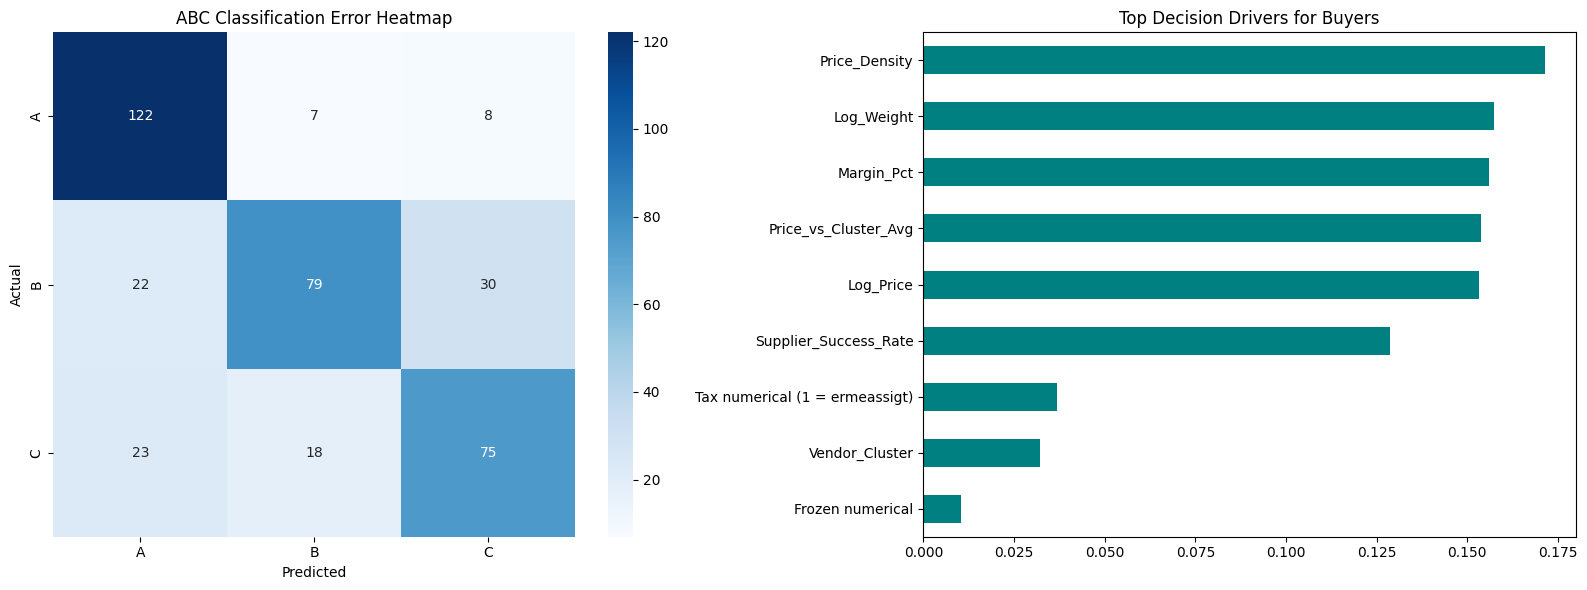


✅ Setup Complete. Ready for Cell 2 (Initial Buy Calculator).


In [8]:
# @title Load Data and Train Model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error, r2_score
from xgboost import XGBClassifier, XGBRegressor
from imblearn.combine import SMOTETomek
import ipywidgets as widgets
from IPython.display import display, clear_output
from google.colab import files
import io

# 1. SETTINGS & WARNING FIXES
pd.set_option('future.no_silent_downcasting', True)

# 2. LOAD & VENDOR CLUSTERING
df_p = pd.read_csv('readymlproducts.csv')
df_v = pd.read_csv('readymlvendor.csv')

v_cols = ['Sales overall', 'Units per day', 'Amount of Products', 'Average Out of Stock', 'Median of Margin']
v_scaler = StandardScaler()
v_scaled = v_scaler.fit_transform(df_v[v_cols])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_v['Vendor_Cluster'] = kmeans.fit_predict(v_scaled)
vendor_map = df_v.set_index('Supplier')['Vendor_Cluster'].to_dict()

# 3. FEATURE ENGINEERING
def engineer_features(df_input, reference_df=None):
    df = df_input.copy()
    for col in ['Net Sales price', 'Purchase', 'Weight']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    if reference_df is not None:
        ref = reference_df.copy()
        ref['A B C'] = ref['A B C'].astype(str).fillna('C')
        ref['Success_Flag'] = ref['A B C'].replace({'A': 1, 'B': 1, 'C': 0}).astype(float)

        global global_supplier_success, global_cluster_avg_price
        global_supplier_success = ref.groupby('Supplier')['Success_Flag'].mean().to_dict()
        global_cluster_avg_price = ref.groupby('Vendor_Cluster')['Net Sales price'].mean().to_dict()

    df['Vendor_Cluster'] = df['Supplier'].map(lambda x: vendor_map.get(x, 0)).fillna(0).astype(int)
    df['Supplier_Success_Rate'] = df['Supplier'].map(global_supplier_success).fillna(0.35)
    avg_price_map = df['Vendor_Cluster'].map(global_cluster_avg_price).fillna(df['Net Sales price'].mean())
    df['Price_vs_Cluster_Avg'] = df['Net Sales price'] - avg_price_map
    df['Margin_Pct'] = np.where(df['Net Sales price'] != 0, (df['Net Sales price'] - df['Purchase']) / df['Net Sales price'], 0)
    df['Price_Density'] = df['Net Sales price'] / df['Weight'].replace(0, 1)
    df['Log_Price'] = np.log1p(df['Net Sales price'].clip(lower=0))
    df['Log_Weight'] = np.log1p(df['Weight'].clip(lower=0))
    return df.replace([np.inf, -np.inf], 0).fillna(0)

df_full = pd.merge(df_p, df_v[['Supplier', 'Vendor_Cluster']], on='Supplier', how='left')
df_engineered = engineer_features(df_full, reference_df=df_full)

# 4. DATA PREP
features_list = ['Vendor_Cluster', 'Supplier_Success_Rate', 'Price_vs_Cluster_Avg', 'Log_Price', 'Log_Weight', 'Margin_Pct', 'Price_Density', 'Tax numerical (1 = ermeassigt)', 'Frozen numerical']
X = df_engineered[features_list]
le = LabelEncoder()
y_abc = le.fit_transform(df_engineered['A B C'].astype(str))

# 5. BALANCING
smt = SMOTETomek(random_state=42)
X_res, y_res = smt.fit_resample(X, y_abc)
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# 6. MODEL INITIALIZATION (With Tuned Hyperparameters)
ensemble_model = VotingClassifier(estimators=[
    ('xgb', XGBClassifier(n_estimators=500, learning_rate=0.01, max_depth=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=2, random_state=42))
], voting='soft')

model_units = XGBRegressor(
    n_estimators=1200, learning_rate=0.1, max_depth=9,
    subsample=0.8, colsample_bytree=0.7, reg_lambda=1.5, reg_alpha=1,
    objective='count:poisson', random_state=42
)

model_sales = XGBRegressor(
    n_estimators=500, learning_rate=0.01, max_depth=9,
    subsample=0.9, colsample_bytree=1.0, reg_lambda=10, reg_alpha=1,
    objective='reg:squarederror', random_state=42
)

# 7. CROSS-VALIDATION
print("🔄 Running 5-Fold Cross-Validation for Classification...")
cv_scores = cross_val_score(ensemble_model, X_res, y_res, cv=5)
print(f"✅ CV Mean Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# 8. FINAL TRAINING
print("\n🚀 Training Final Optimized Models...")
ensemble_model.fit(X_train, y_train)
model_units.fit(X, df_engineered['Unit_sold_day'])
model_sales.fit(X, df_engineered['Sales'])

# 9. RESULTS DASHBOARD
print("\n" + "="*50)
print("📈 BUYER'S MODEL PERFORMANCE DASHBOARD")
print("="*50)

# Classification Results
y_pred = ensemble_model.predict(X_test)
print("\n📊 ABC Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Regression Results
u_preds = model_units.predict(X)
s_preds = model_sales.predict(X)

print("\n📈 Regression Analytics (Full Dataset):")
print(f"Units/Day   -> MAE: {mean_absolute_error(df_engineered['Unit_sold_day'], u_preds):.4f} | R2: {r2_score(df_engineered['Unit_sold_day'], u_preds):.4f}")
print(f"30-Day Rev. -> MAE: €{mean_absolute_error(df_engineered['Sales'], s_preds):.2f} | R2: {r2_score(df_engineered['Sales'], s_preds):.4f}")

# 10. VISUALIZATION


fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=ax[0])
ax[0].set_title("ABC Classification Error Heatmap")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

# Feature Importance
rf_feat = pd.Series(ensemble_model.named_estimators_['rf'].feature_importances_, index=features_list).sort_values()
rf_feat.plot(kind='barh', color='teal', ax=ax[1])
ax[1].set_title("Top Decision Drivers for Buyers")

plt.tight_layout()
plt.show()

print("\n✅ Setup Complete. Ready for Cell 2 (Initial Buy Calculator).")

In [ ]:
# @title Predict Single Items
# Ensure the list of vendors is pulled from our actual data
vendors = sorted(list(vendor_map.keys()))
style = {'description_width': 'initial'}

# --- UI Setup ---
w_supplier = widgets.Dropdown(options=vendors, description='Supplier:', style=style)
w_purchase = widgets.FloatText(value=0.50, description='Purchase Price (€):', style=style)
w_sales = widgets.FloatText(value=1.50, description='Sales Price (€):', style=style)
w_weight = widgets.FloatText(value=100.0, description='Weight (units):', style=style)
w_frozen = widgets.Dropdown(options=[('Yes', 1), ('No', 0)], value=0, description='Frozen?', style=style)

# UPDATED: Reduced Tax (1) is now the default starting value
w_tax = widgets.Dropdown(
    options=[('Reduced (7%)', 1), ('Standard (19%)', 0)],
    value=1,
    description='Tax Category:',
    style=style
)

button = widgets.Button(description="Analyze Product", button_style='success', icon='search')
output = widgets.Output()

def on_button_clicked(b):
    with output:
        clear_output()
        # 1. Prepare input
        input_df = pd.DataFrame([{
            'Supplier': w_supplier.value,
            'Purchase': w_purchase.value,
            'Net Sales price': w_sales.value,
            'Weight': w_weight.value,
            'Frozen numerical': w_frozen.value,
            'Tax numerical (1 = ermeassigt)': w_tax.value
        }])

        # 2. Engineer features using global reference from Cell 1
        processed = engineer_features(input_df, reference_df=None)
        features = processed[features_list]

        # 3. Model Predictions
        cat_idx = ensemble_model.predict(features)[0]
        cat_label = le.classes_[cat_idx]

        # FULL PROBABILITY BREAKDOWN
        all_probs = ensemble_model.predict_proba(features)[0]
        prob_dict = dict(zip(le.classes_, all_probs))

        # Regression Predictions (Poisson & Regressor)
        units_per_day = max(0, model_units.predict(features)[0])
        est_sales_30d = max(0, model_sales.predict(features)[0])

        # 4. Supply Chain Logic (Monthly PO at 0.85 Velocity)
        initial_buy_volume = round((units_per_day * 30) * 0.85)

        # 5. Display Results
        print(f"📦 ANALYSIS COMPLETE: {w_supplier.value}")
        print(f"--------------------------------------------------")
        print(f"PREDICTED RANK        : Category {cat_label}")
        print(f"DAILY VELOCITY        : {units_per_day:.4f} units/day")
        print(f"EST. 30-DAY REVENUE   : €{est_sales_30d:.2f}")
        print(f"--------------------------------------------------")

        print("📊 CLASS PROBABILITY BREAKDOWN:")
        for cls, p in prob_dict.items():
            bar_length = int(p * 20)
            bar = "█" * bar_length
            print(f"  Class {cls}: {p*100:5.1f}% {bar}")

        print(f"--------------------------------------------------")
        print(f"💡 RECOMMENDED INITIAL BUY (30 Days at 0.85 Velocity)")
        print(f"ORDER QUANTITY        : {initial_buy_volume} units")

        # Detailed logic for buyer review
        if prob_dict[cat_label] < 0.55:
            # Sort probabilities to find the runner-up
            sorted_probs = sorted(prob_dict.items(), key=lambda x: x[1], reverse=True)
            runner_up_cat = sorted_probs[1][0]
            runner_up_val = sorted_probs[1][1] * 100
            print(f"\n⚠️  STABILITY ALERT: This is a close call between {cat_label} and {runner_up_cat}.")
            print(f"    (Class {runner_up_cat} has a {runner_up_val:.1f}% probability).")

button.on_click(on_button_clicked)

# Render Widget
print("🚀 Product Selection Tool")
display(widgets.VBox([
    w_supplier,
    widgets.HBox([w_purchase, w_sales]),
    widgets.HBox([w_weight, w_frozen, w_tax]),
    button,
    output
]))

In [ ]:
# @title Predict Batch of New Items


# --- 1. THE BUYER'S TEMPLATE GUIDE ---
print("📘 CSV UPLOAD GUIDE")
print("Your 'buyer_upload.csv' must have these EXACT column headers:")
print("-" * 105)

# Creating a visual example of the required input including Product Name
template_data = {
    'Product Name': ['Mediterranean Delights', 'Tropical Tastes', 'Bistro Basics'],
    'Supplier': ['Global Grains Co.', 'Alpine Dairy Group', 'Eco-Groceries'],
    'Net Sales price': [4.99, 12.50, 6.90],
    'Purchase': [2.10, 6.50, 3.20],
    'Weight': [0.6, 5.1, 0.45],
    'Tax numerical (1 = ermeassigt)': [1, 1, 1],
    'Frozen numerical': [0, 0, 1]
}
template_example = pd.DataFrame(template_data)
print(template_example.to_string(index=False))
print("-" * 105)
print("💡 Tip: 'Product Name' is for your reference. Use 1 for Reduced Tax (7%) / Frozen.")

# --- 2. UPLOAD SECTION ---
print("\n📤 Please upload your CSV file now:")
uploaded = files.upload()

try:
    # Load the file
    filename = list(uploaded.keys())[0]
    buyer_df = pd.read_csv(io.BytesIO(uploaded[filename]))

    # Check if all required columns exist
    required_in = ['Product Name', 'Supplier', 'Net Sales price', 'Purchase', 'Weight',
                   'Tax numerical (1 = ermeassigt)', 'Frozen numerical']
    missing = [col for col in required_in if col not in buyer_df.columns]

    if missing:
        raise ValueError(f"Missing columns in CSV: {missing}")

    print(f"\n✅ '{filename}' loaded. Analyzing {len(buyer_df)} products...")

    # --- 3. DATA SHIELD ---
    shield_mapping = {
        '1': 1, '1.0': 1, 'yes': 1, 'frozen': 1, 'ermeassigt': 1, 'reduced': 1, 'true': 1, '7%': 1,
        '0': 0, '0.0': 0, 'no': 0, 'dry': 0, 'fresh': 0, 'standard': 0, 'false': 0, 'nan': 0, '19%': 0
    }

    for col in ['Tax numerical (1 = ermeassigt)', 'Frozen numerical']:
        buyer_df[col] = buyer_df[col].astype(str).str.lower().str.strip().map(shield_mapping).fillna(0).astype(int)

    # --- 4. PREDICTIONS ---
    buyer_eng = engineer_features(buyer_df, reference_df=None)
    probs = ensemble_model.predict_proba(buyer_eng[features_list])

    # Probability Columns
    for i, label in enumerate(le.classes_):
        buyer_df[f'Prob_{label}_%'] = (probs[:, i] * 100).round(1)

    # Classification and AI Confidence
    preds_abc_idx = ensemble_model.predict(buyer_eng[features_list])
    buyer_df['Predicted_ABC'] = le.inverse_transform(preds_abc_idx)
    buyer_df['AI_Confidence_%'] = (probs.max(axis=1) * 100).round(1)

    # Forecasting
    buyer_df['Pred_Units_Day'] = model_units.predict(buyer_eng[features_list]).clip(0).round(4)
    # The 0.85 Strategy: (Daily Units * 30) * 0.85
    buyer_df['Initial_Buy_30D_0.85'] = (buyer_df['Pred_Units_Day'] * 30 * 0.85).round(0).astype(int)
    buyer_df['Pred_Monthly_Rev'] = model_sales.predict(buyer_eng[features_list]).clip(0).round(2)

    # --- 5. EXPORT PREPARATION ---
    # Product Name is now the first column
    export_cols = [
        'Product Name', 'Supplier', 'Net Sales price', 'Purchase', 'Weight', 'Predicted_ABC',
        'AI_Confidence_%', 'Prob_A_%', 'Prob_B_%', 'Prob_C_%',
        'Pred_Units_Day', 'Initial_Buy_30D_0.85', 'Pred_Monthly_Rev'
    ]

    final_report = buyer_df[export_cols]
    final_report.to_csv('final_procurement_report.csv', index=False)

    print("\n" + "="*70)
    print("🚀 PROCUREMENT REPORT GENERATED")
    print("="*70)
    display(final_report.head(5))

    # Download the result automatically
    files.download('final_procurement_report.csv')

except Exception as e:
    print(f"\n❌ ERROR: {str(e)}")
    print("Please ensure your CSV matches the guide headers exactly.")